Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5

Validation Accuracy: 0.9444444444444444

Classification Report (Validation):
              precision    recall  f1-score   support

   BlueNoise       0.93      0.93      0.93        69
  BrownNoise       0.89      0.96      0.92        69
       Clean       0.94      0.90      0.92        69
   PinkNoise       0.99      1.00      0.99        69
 VioletNoise       0.94      0.94      0.94        69
  WhiteNoise       0.98      0.94      0.96        69

    accuracy                           0.94       414
   macro avg       0.95      0.94      0.94       414
weighted avg       0.95      0.94      0.94       414


Confusion Matrix (Validation):
[[64  0  0  0  4  1]
 [ 0 66  3  0  0  0]
 [ 0  7 62  0  0  0]
 [ 0  0  0 69  0  0]
 [ 2  1  1  0 65  0]
 [ 3  0  0  1  0 65]]

Unikke targets i test: [0 1 2 3 4 5]
Antal prøver pr. klasse: [100 100 100 100 100 100]

Test Accuracy: 0.9466666

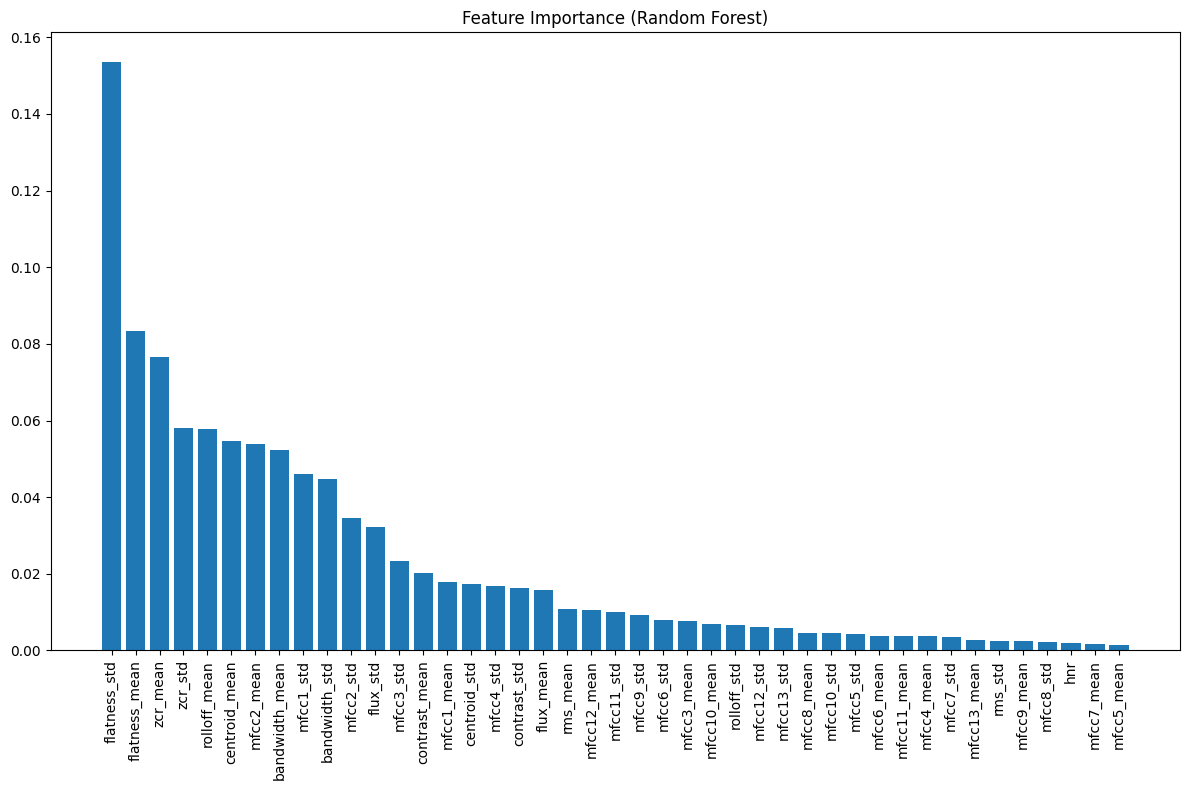


Top 15 vigtigste features:
flatness_std: 0.1536
flatness_mean: 0.0835
zcr_mean: 0.0765
zcr_std: 0.0580
rolloff_mean: 0.0577
centroid_mean: 0.0546
mfcc2_mean: 0.0538
bandwidth_mean: 0.0523
mfcc1_std: 0.0460
bandwidth_std: 0.0447
mfcc2_std: 0.0346
flux_std: 0.0321
mfcc3_std: 0.0232
contrast_mean: 0.0203
mfcc1_mean: 0.0179


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv"
df_train = pd.read_csv(train_path)

# Fjern irrelevant features
irrelevant_cols = ["filnavn", "beta", "snr_db"]  # fjern beta og snr fra features
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])


# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Klasse mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. RANDOM FOREST MODEL
# ----------------------------
model = RandomForestClassifier(
    n_estimators=300,      # antal træer (svarer lidt til XGBoost n_estimators)
    max_depth=6,           # maks dybde pr. træ
    max_features="sqrt",   # typisk standardvalg
    bootstrap=True,
    random_state=42,
    n_jobs=-1              # bruger alle CPU-kerner
)

model.fit(X_train, y_train)

# ----------------------------
# 5. VALIDATION EVALUATION
# ----------------------------
y_val_pred = model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. TEST ON SEPARATE DATASET
# ----------------------------
test_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv"
df_test = pd.read_csv(test_path)

# Fjern irrelevant features
for col in irrelevant_cols:
    if col in df_test.columns:
        df_test = df_test.drop(columns=[col])


# Split features og labels korrekt
X_test = df_test.drop(columns=["target"])
y_test_true = label_encoder.transform(df_test["target"])

print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

# ----------------------------
# 7. FEATURE IMPORTANCE
# ----------------------------
importances = model.feature_importances_
feature_names = X.columns

# Sorter features efter importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")